### Create anndata object for Grün, 2016 LGR5+ stem cells

- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 10th September 2024
- **Last modified date:** 13th November 2024

This notebook intends to create anndata object from data deposited in GEO under accession number `GSE76408`. The raw data was remapped with `StarSolo`to obtain the raw counts.

Additionall, we perform basic QC analysis and filter out low quality cells.

### Import packages

In [102]:
import pandas as pd
import anndata as ad
import numpy as np
from scipy.io import mmread
import os
from datetime import datetime
import scanpy as sc
import sctk
import seaborn as sns
import matplotlib.pyplot as plt
import json

### Create anndata object

In [26]:
base_dir = "raw_fastq_files/Grün_2016"

In [27]:
metadata = pd.read_csv(f"{base_dir}/SraRunTable.txt", sep=',')

metadata = metadata[['Run', 'Instrument', 'Sample Name', 'source_name', 'SRA Study', 'strain', 'tissue']]
metadata.set_index('Run', inplace=True)

In [28]:
with open(f"{base_dir}/SRR_Acc_List.txt", 'r') as f:
    samples = [line.strip() for line in f]

adatas = []

for sample in samples:
    print(f"Processing {sample}...")
    
    matrix_dir = f"{base_dir}/{sample}/star_output/{sample}_Solo.out/Gene/raw"
    
    try:
        mtx = mmread(os.path.join(matrix_dir, "matrix.mtx")).T.tocsr()
        features = pd.read_csv(os.path.join(matrix_dir, "features.tsv"), 
                             header=None, sep="\t")
        barcodes = pd.read_csv(os.path.join(matrix_dir, "barcodes.tsv"), 
                              header=None, sep="\t")
        
        adata = ad.AnnData(X=mtx,
                          obs=pd.DataFrame(index=barcodes[0]),
                          var=pd.DataFrame(index=features[0]))
        
        adata.obs['sample'] = sample
        
        for col in metadata.columns:
            adata.obs[col] = metadata.loc[sample, col]
        
        adatas.append(adata)
        print(f"Successfully processed {sample}")
        
    except Exception as e:
        print(f"Error processing {sample}: {str(e)}")
        continue

print("Concatenating samples...")
combined_adata = ad.concat(adatas, join='outer', label='sample')

Processing SRR3063726...
Successfully processed SRR3063726
Processing SRR3063725...
Successfully processed SRR3063725
Processing SRR3063724...
Successfully processed SRR3063724
Processing SRR3063723...
Successfully processed SRR3063723
Processing SRR3063722...
Successfully processed SRR3063722
Processing SRR3063721...
Successfully processed SRR3063721
Processing SRR3063728...
Successfully processed SRR3063728
Processing SRR3063729...
Successfully processed SRR3063729
Processing SRR3063731...
Successfully processed SRR3063731
Processing SRR3063730...
Successfully processed SRR3063730
Concatenating samples...


/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [29]:
combined_adata.obs['cell_type'] = 'LGR5+ stem cell'

In [32]:
combined_adata.obs

,sample,Instrument,Sample Name,source_name,SRA Study,strain,tissue,cell_type,cell_id
cell_id,,,,,,,,,
ACAGTATC_GSM1987576,0,NextSeq 500,GSM1987576,"Extracted RNA 3-week traced Lgr5+ cells\, CD24...",SRP067892,Lgr5-CreERT2 C57Bl6/J mice bred to a Rosa26LSL...,Small intestine,LGR5+ stem cell,ACAGTATC_GSM1987576
ACAGTCGA_GSM1987576,0,NextSeq 500,GSM1987576,"Extracted RNA 3-week traced Lgr5+ cells\, CD24...",SRP067892,Lgr5-CreERT2 C57Bl6/J mice bred to a Rosa26LSL...,Small intestine,LGR5+ stem cell,ACAGTCGA_GSM1987576
ACGACATC_GSM1987576,0,NextSeq 500,GSM1987576,"Extracted RNA 3-week traced Lgr5+ cells\, CD24...",SRP067892,Lgr5-CreERT2 C57Bl6/J mice bred to a Rosa26LSL...,Small intestine,LGR5+ stem cell,ACGACATC_GSM1987576
ACGACCGC_GSM1987576,0,NextSeq 500,GSM1987576,"Extracted RNA 3-week traced Lgr5+ cells\, CD24...",SRP067892,Lgr5-CreERT2 C57Bl6/J mice bred to a Rosa26LSL...,Small intestine,LGR5+ stem cell,ACGACCGC_GSM1987576
ACGACGAA_GSM1987576,0,NextSeq 500,GSM1987576,"Extracted RNA 3-week traced Lgr5+ cells\, CD24...",SRP067892,Lgr5-CreERT2 C57Bl6/J mice bred to a Rosa26LSL...,Small intestine,LGR5+ stem cell,ACGACGAA_GSM1987576
...,...,...,...,...,...,...,...,...,...
TGCATCGA_GSM1987581,9,NextSeq 500,GSM1987581,"Extracted RNA 8-week traced Lgr5+ cells\, CD24...",SRP067892,Lgr5-CreERT2 C57Bl6/J mice bred to a Rosa26LSL...,Small intestine,LGR5+ stem cell,TGCATCGA_GSM1987581
TGCATGAT_GSM1987581,9,NextSeq 500,GSM1987581,"Extracted RNA 8-week traced Lgr5+ cells\, CD24...",SRP067892,Lgr5-CreERT2 C57Bl6/J mice bred to a Rosa26LSL...,Small intestine,LGR5+ stem cell,TGCATGAT_GSM1987581
TGCATTCG_GSM1987581,9,NextSeq 500,GSM1987581,"Extracted RNA 8-week traced Lgr5+ cells\, CD24...",SRP067892,Lgr5-CreERT2 C57Bl6/J mice bred to a Rosa26LSL...,Small intestine,LGR5+ stem cell,TGCATTCG_GSM1987581


In [31]:
combined_adata.obs['cell_id'] = combined_adata.obs.index + '_' + combined_adata.obs['Sample Name']
combined_adata.obs.index = combined_adata.obs['cell_id']

In [35]:
combined_adata.var['ensemble_gene_id'] = combined_adata.var.index.copy()
combined_adata.var.index = combined_adata.var['ensemble_gene_id']

In [36]:
project = 'gut'
species = 'mm'
atribute = 'Grün2016_LGR5_SC'
name = 'AM'
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
counts = 'raw'

combined_adata.uns['processing_history'] = []
combined_adata.uns['processing_history']={
    'timestamp': timestamp,
    'step': 'create raw anndata after mapping, no filtering'}

combined_adata.write_h5ad(f"{base_dir}/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

### Quality check

In [71]:
combined_adata = sc.read_h5ad(f"{base_dir}/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [72]:
combined_adata

AnnData object with n_obs × n_vars = 960 × 57186
    obs: 'sample', 'Instrument', 'Sample Name', 'source_name', 'SRA Study', 'strain', 'tissue', 'cell_type', 'cell_id'
    var: 'ensemble_gene_id'
    uns: 'processing_history'

In [73]:
sc.pp.filter_cells(combined_adata, min_genes=100)
sc.pp.filter_genes(combined_adata, min_cells=1)
combined_adata

AnnData object with n_obs × n_vars = 587 × 15890
    obs: 'sample', 'Instrument', 'Sample Name', 'source_name', 'SRA Study', 'strain', 'tissue', 'cell_type', 'cell_id', 'n_genes'
    var: 'ensemble_gene_id', 'n_cells'
    uns: 'processing_history'

* change ensemble gene id to gene name 

In [74]:
annot = sc.queries.biomart_annotations(
        "mmusculus",
        ["ensembl_gene_id", "external_gene_name", "start_position", "end_position", "chromosome_name"],
    ).set_index("external_gene_name")

In [75]:
annot["gene_name"] = annot.index

In [76]:
combined_adata.var['ensemble_gene_id'] = combined_adata.var['ensemble_gene_id'].str.split('.').str[0]

In [77]:
combined_adata.var.index.name = 'gene_id'

In [78]:
combined_adata.var = combined_adata.var.merge(annot, left_on='ensemble_gene_id', right_on='ensembl_gene_id', how='left')

In [80]:
combined_adata.var.index = combined_adata.var['gene_name'].copy()

In [85]:
combined_adata.var.index = combined_adata.var.index.astype(str)

+ Check mitochondrial and ribosomal percentage

In [90]:
combined_adata.var['mt'] = combined_adata.var_names.str.startswith('mt-') 
combined_adata.var['ribo'] = combined_adata.var_names.str.startswith(("Rps","Rpl"))

In [92]:
sc.pp.calculate_qc_metrics(combined_adata, qc_vars = ['mt','ribo'], percent_top = None, log1p = False, inplace = True)

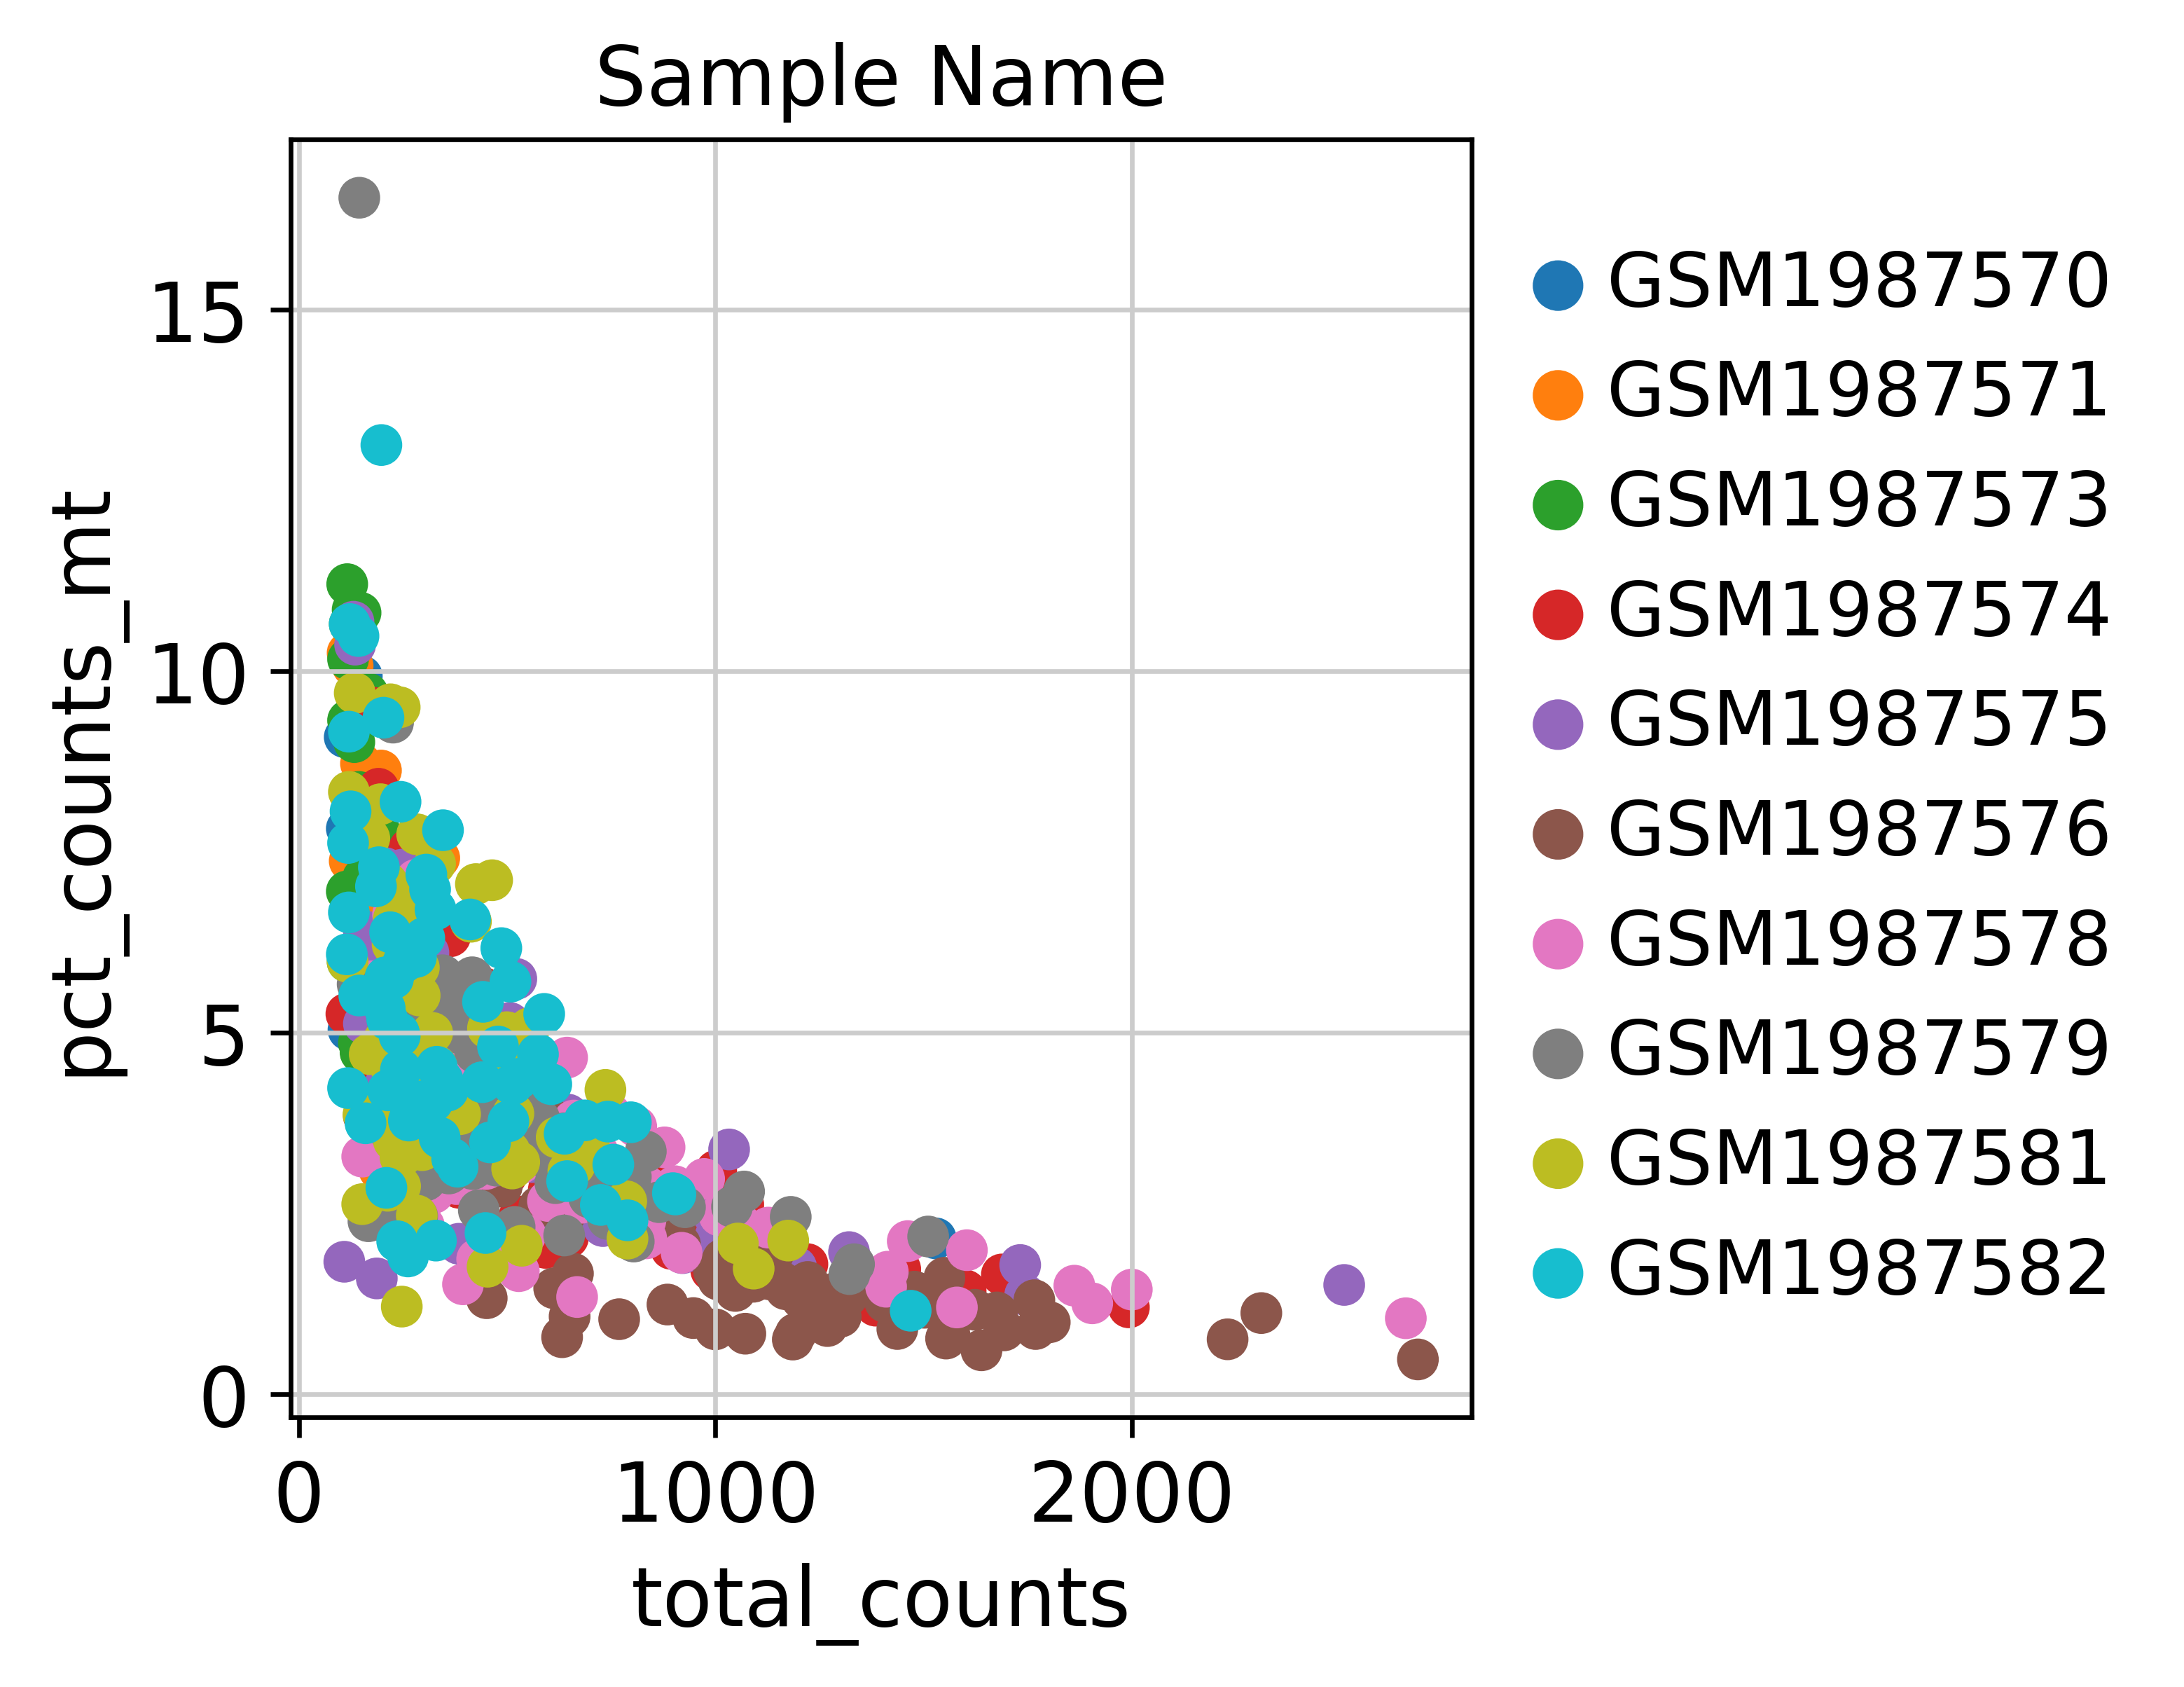

In [109]:
sc.set_figure_params(dpi=300, figsize=(4,4))
sc.pl.scatter(combined_adata, x = 'total_counts', y = 'pct_counts_mt', color = "Sample Name")

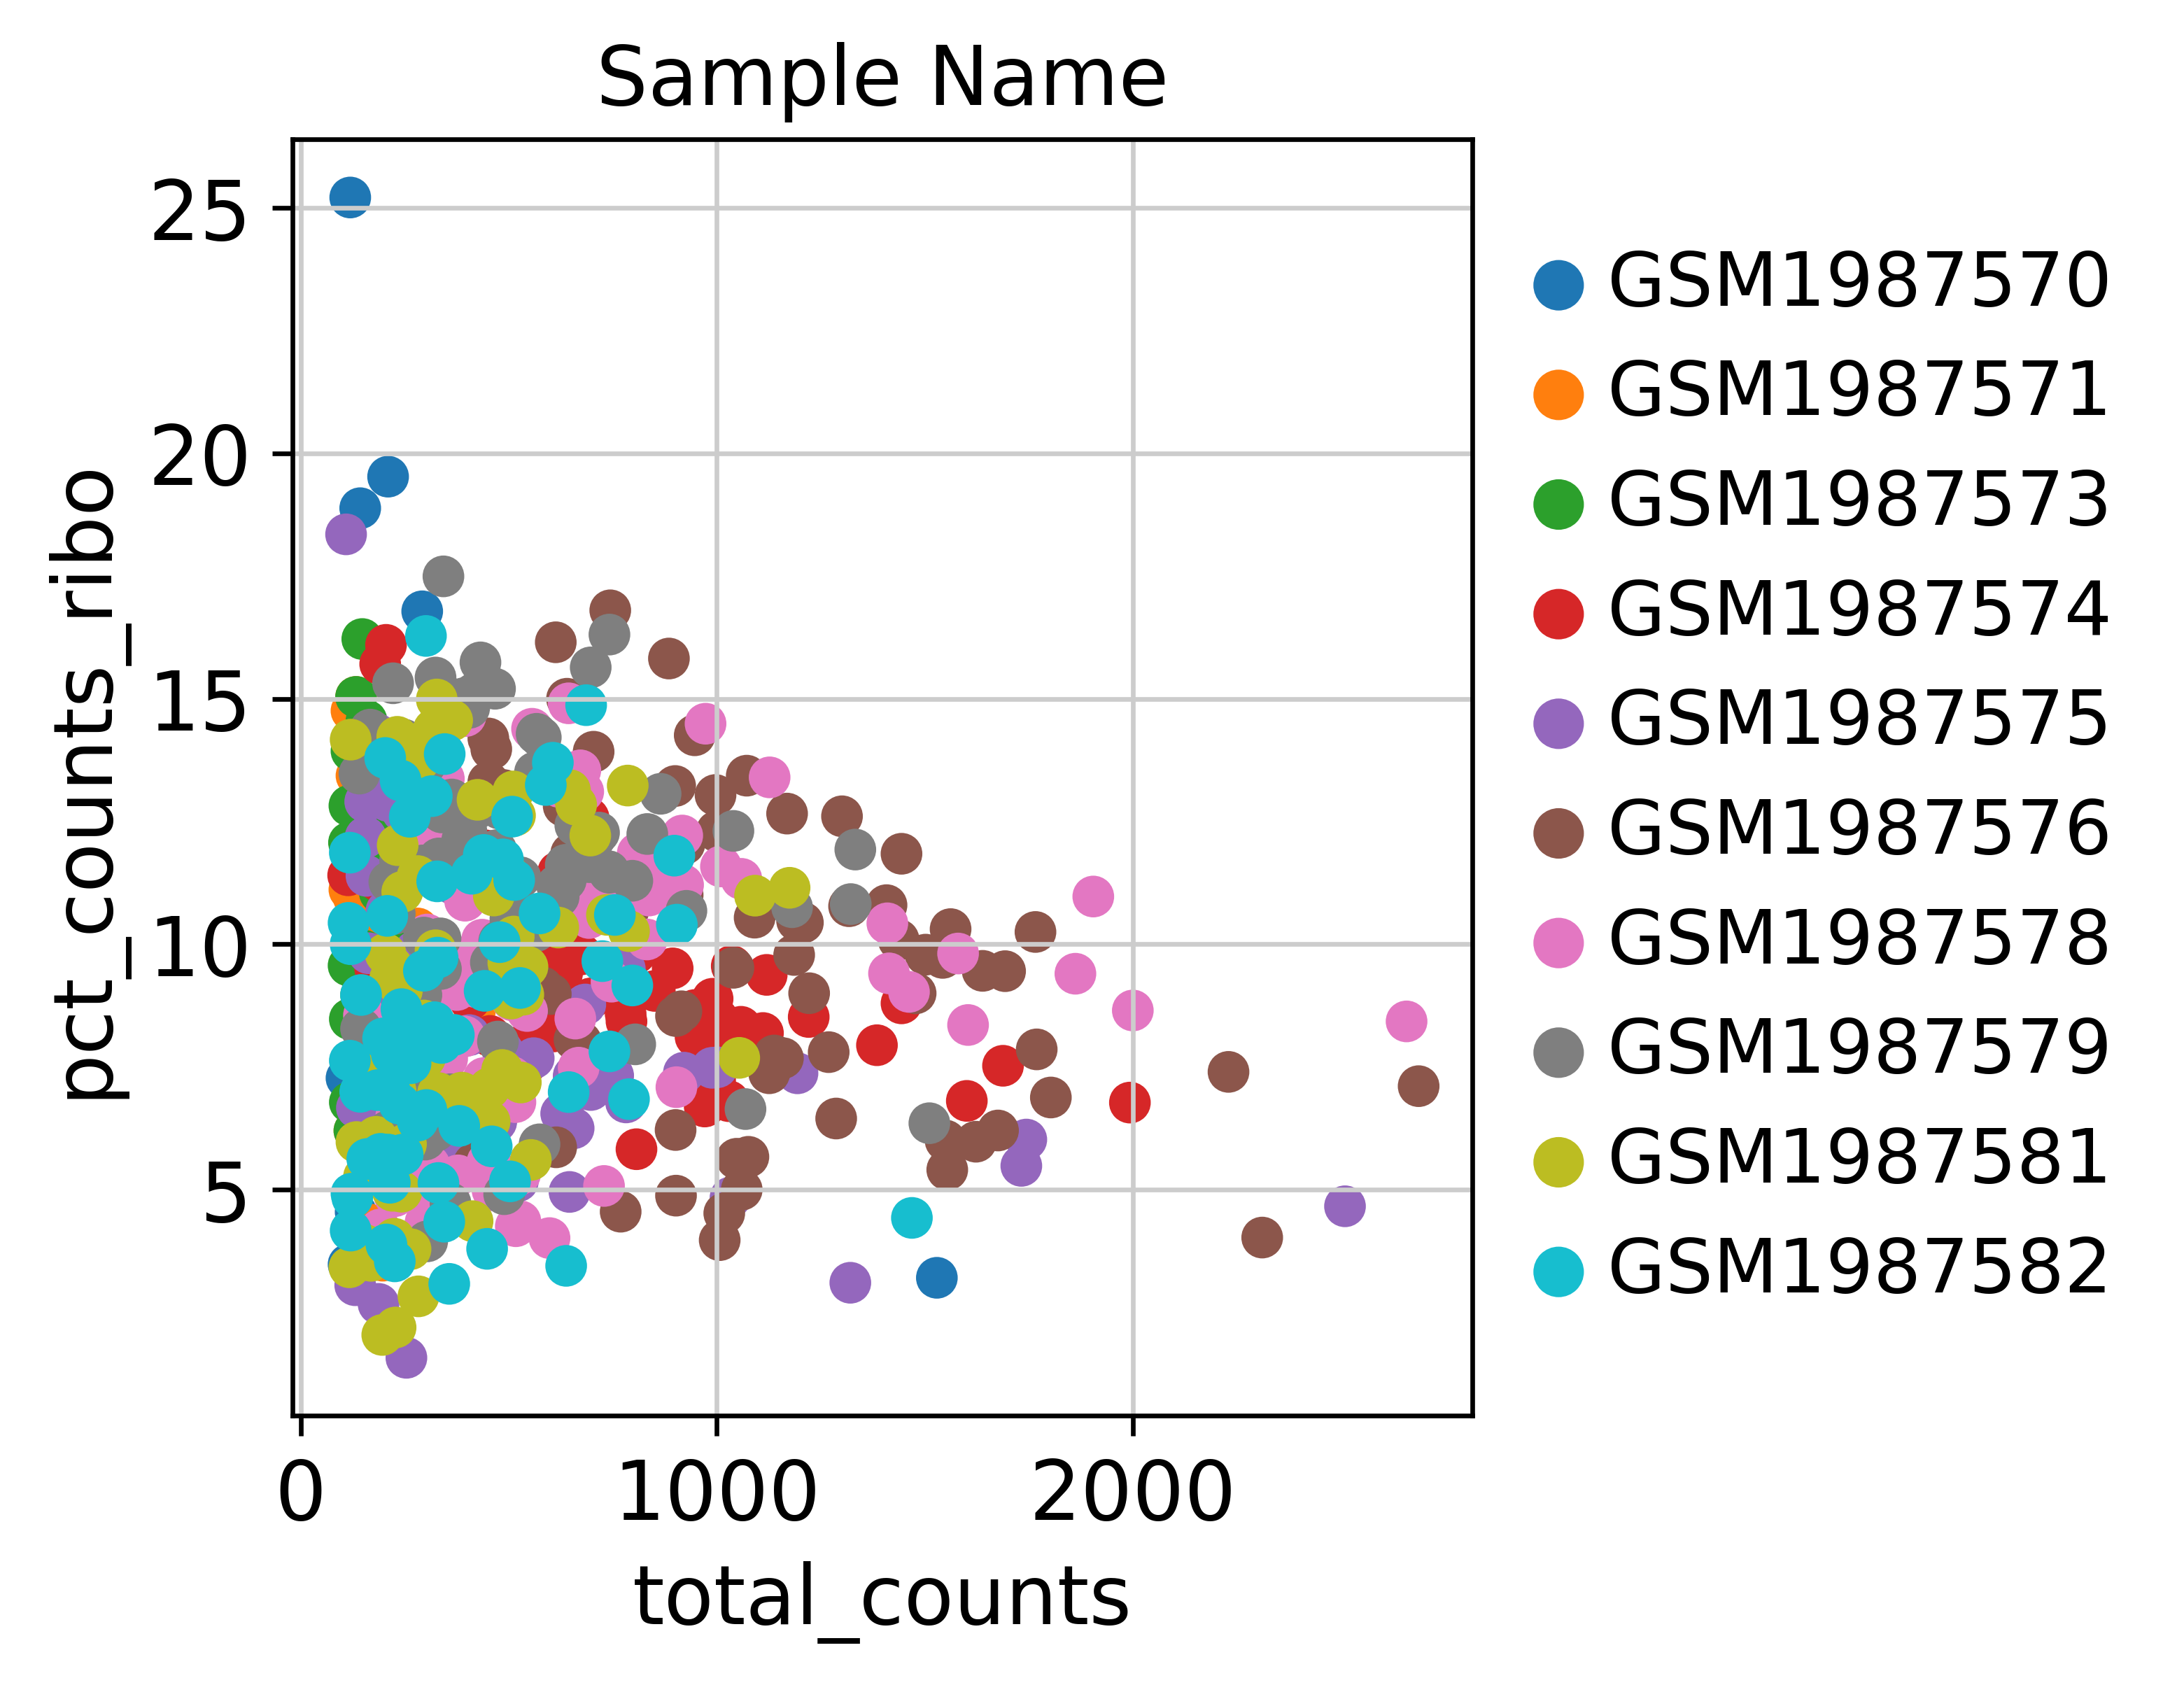

In [108]:
sc.set_figure_params(dpi=300, figsize=(4,4))
sc.pl.scatter(combined_adata, x = 'total_counts', y = 'pct_counts_ribo', color = "Sample Name")

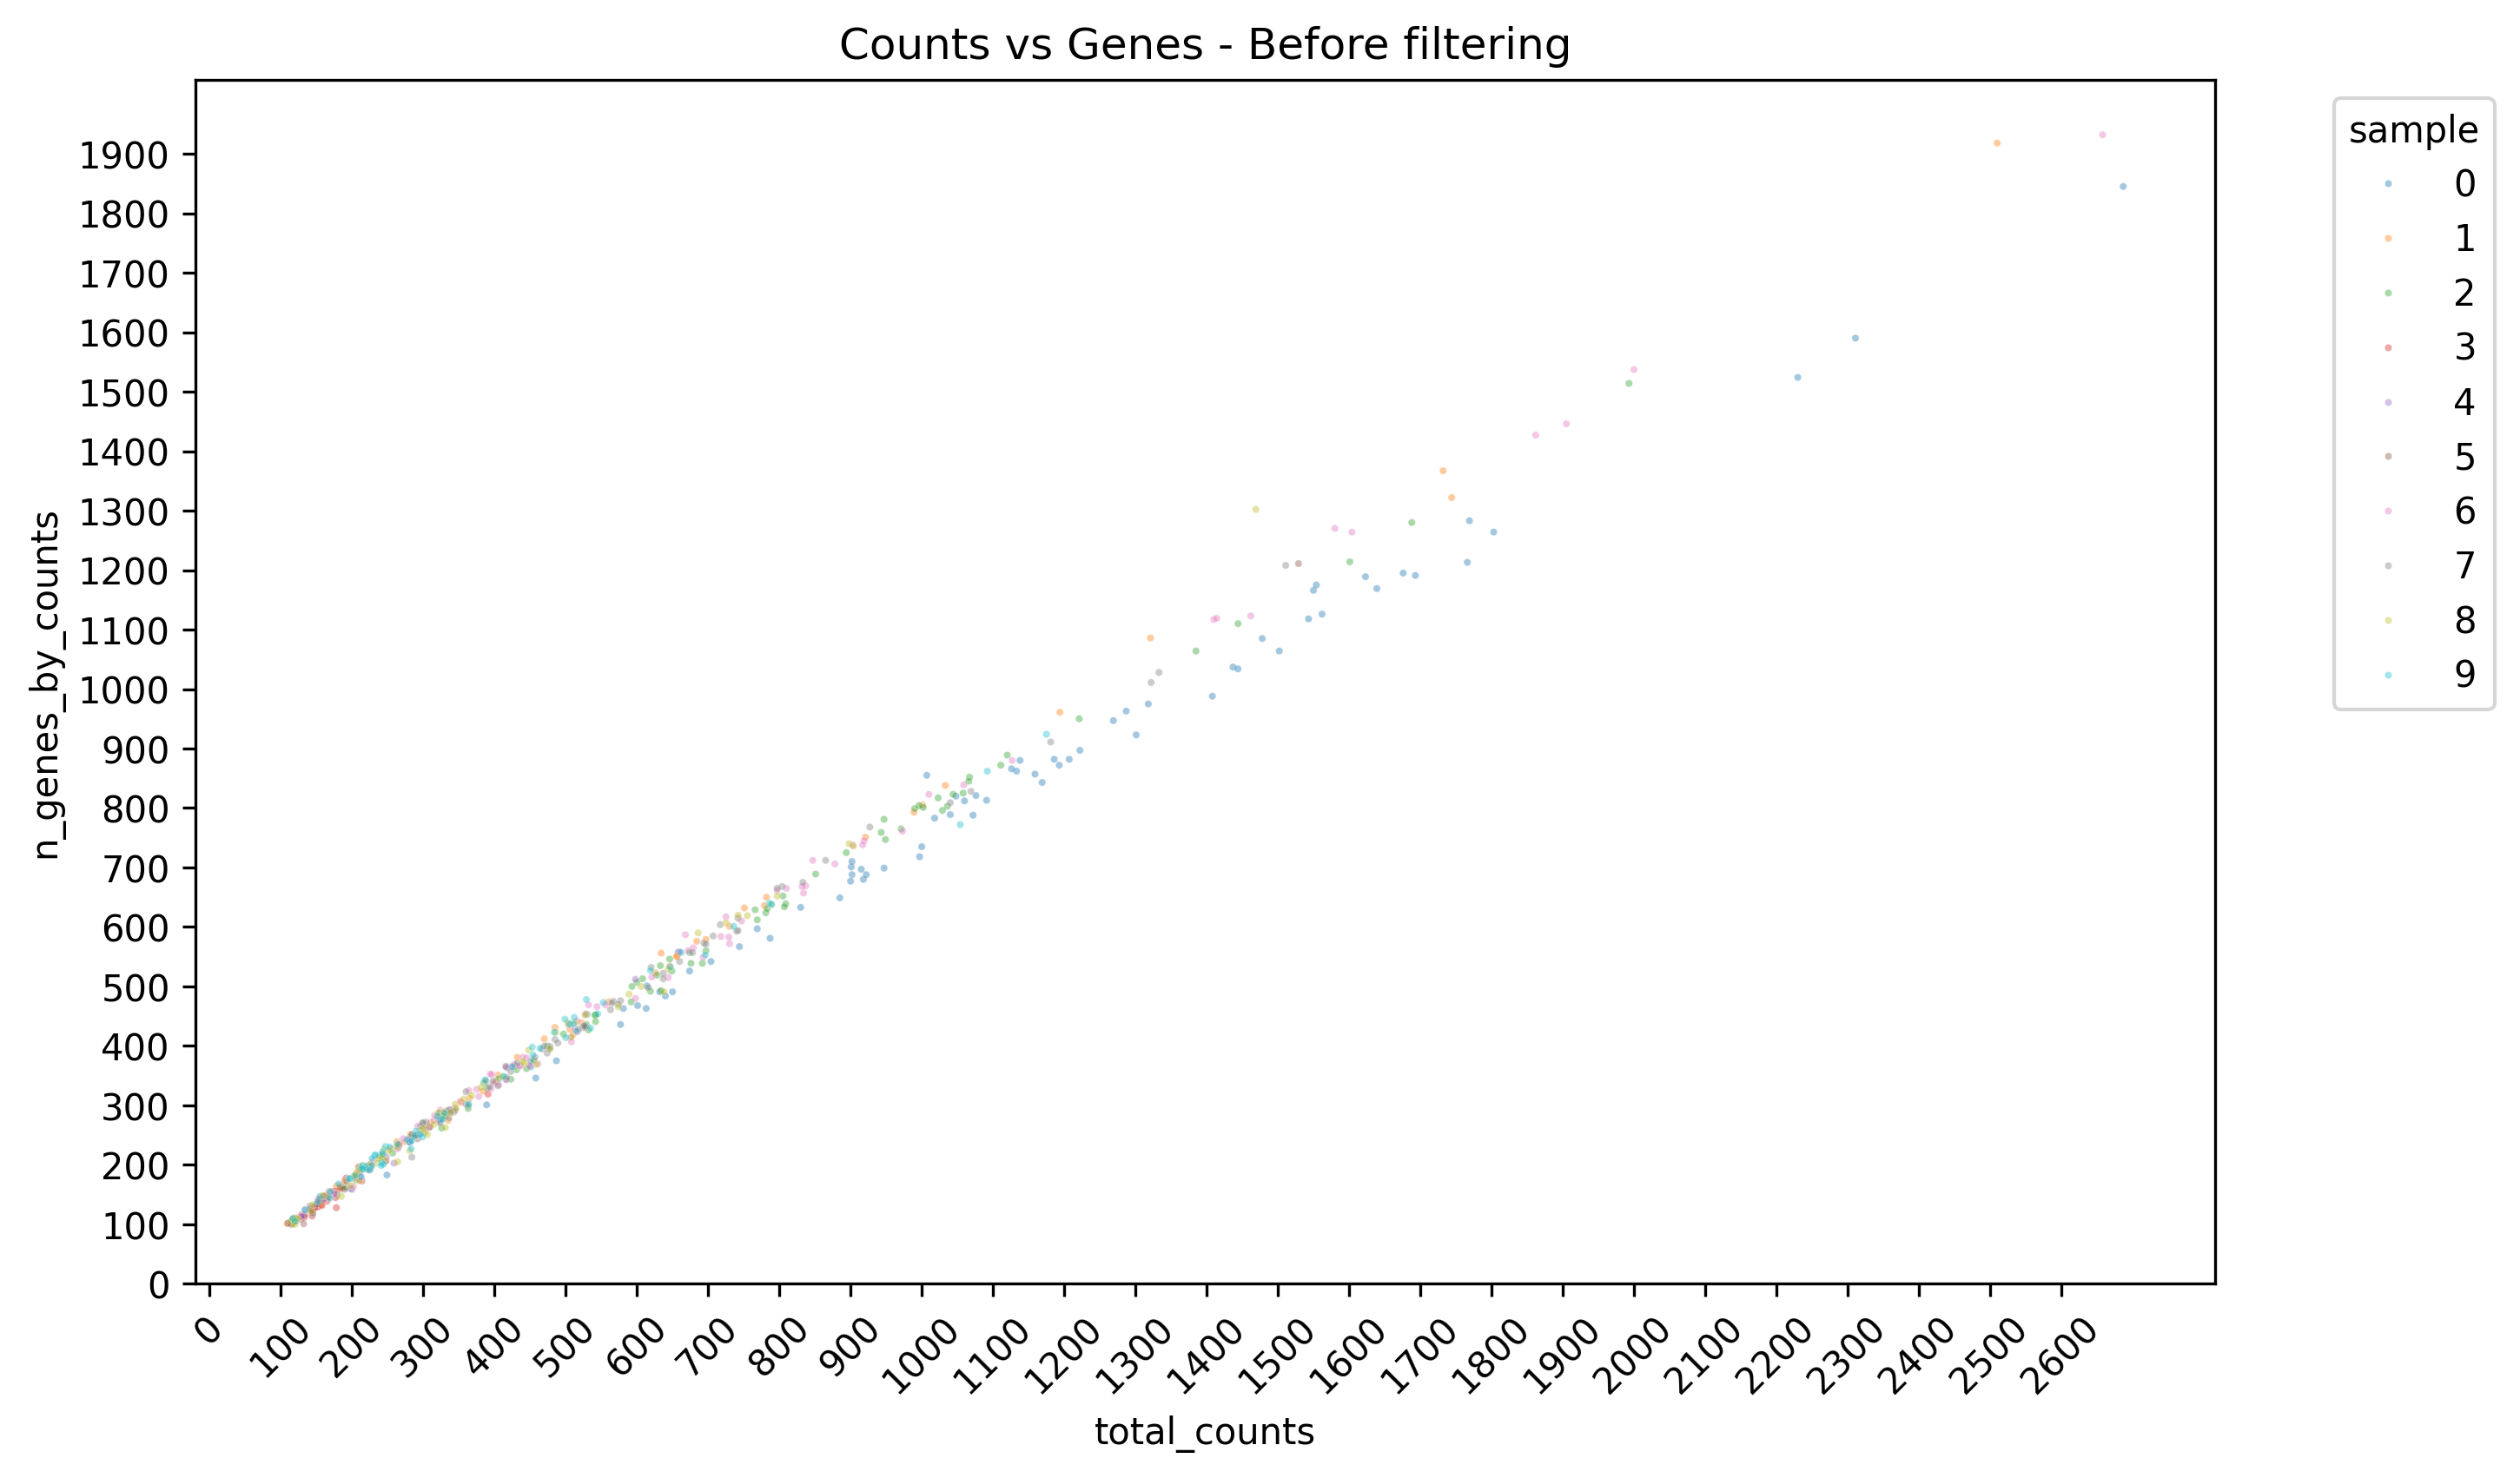

In [98]:
plt.figure(figsize=(10, 6), dpi=300)
sns.scatterplot(data=combined_adata.obs, x='total_counts', y='n_genes_by_counts' , hue ='sample', alpha = 0.4, s=4)
plt.legend(title='sample', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(0, int(max(combined_adata.obs['total_counts'])) + 1, 100),rotation=45, fontsize = 10)
plt.yticks(range(0, int(max(combined_adata.obs['n_genes_by_counts'])) + 1, 100),fontsize = 10)
plt.title(f'Counts vs Genes - Before filtering')
plt.show()

In [99]:
adata_filtered = combined_adata[combined_adata.obs['n_genes_by_counts'] > 50]
adata_filtered = adata_filtered[adata_filtered.obs['n_genes_by_counts'] < 2000]

adata_filtered = adata_filtered[adata_filtered.obs['total_counts'] > 50]
adata_filtered = adata_filtered[adata_filtered.obs['total_counts'] < 2000]

adata_filtered = adata_filtered[adata_filtered.obs['pct_counts_mt'] < 40]
adata_filtered = adata_filtered[adata_filtered.obs['pct_counts_ribo'] < 40]

In [104]:
project = 'gut'
species = 'mm'
atribute = 'Grün2016_LGR5_SC_QC'
name = 'AM'
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
counts = 'raw'

current_history = adata_filtered.uns['processing_history']
new_history = [
    json.dumps(current_history),
    json.dumps({
         'timestamp': timestamp,
         'step': 'added QC metrics, filtered min_genes=100, min_cells=1, n_genes_by_counts>50&<2000, total_counts>50&<2000, pct_counts_mt<40, pct_counts_ribo<40',
    })
]

adata_filtered.uns['processing_history'] = new_history 

adata_filtered.write_h5ad(f"{base_dir}/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")